
---

# 🌳 ***`Decision Trees — Hyperparameters, Overfitting, and Underfitting`***  

---

## ✅ **Introduction**  
📌 **Decision Trees** are powerful yet prone to **overfitting** or **underfitting** if not properly tuned.  
📌 Fine-tuning the **hyperparameters** is crucial to achieve a model that generalizes well on unseen data.  

---

# 🔧 **1. Key Hyperparameters in Decision Trees**  

Tuning these hyperparameters helps control the **tree structure**, improving performance and reducing overfitting.  

---

## 🔹 **1.1. `criterion` (Impurity Measure)**
Determines how the model evaluates the quality of splits.  

| **Value** | **Description** | **Best Use Case** |
|:------------|:----------------|:------------------|
| **`gini`** (default) | Measures **Gini Impurity** (faster computation) | General classification tasks |
| **`entropy`** | Measures **Information Gain** (slightly slower) | When probabilities are important |



## 🔹 **1.2. `max_depth` (Maximum Depth of the Tree)**
Limits the depth of the tree to control complexity.  

| **Effect**             | **Explanation** |
|------------------------|------------------|
| **Low `max_depth`** → Underfitting | Too shallow → Misses important patterns |
| **High `max_depth`** → Overfitting | Too deep → Memorizes training data |

✅ **Recommended Strategy:** Start with `max_depth = 3` to `10` and tune accordingly.  

---

## 🔹 **1.3. `min_samples_split` (Minimum Samples to Split a Node)**
Controls the **minimum number of samples** required to split a node.  

| **Value**             | **Effect** |
|-----------------------|-------------|
| **Low Value (e.g., 2)** | Tree grows aggressively (risk of overfitting) |
| **Higher Value (e.g., 10, 20)** | Reduces overfitting by limiting splits |

✅ **Recommended Strategy:** Use `min_samples_split = 5` or `10` for robust trees.  

---

## 🔹 **1.4. `min_samples_leaf` (Minimum Samples per Leaf Node)**
Ensures each **leaf node** has a minimum number of samples.  

| **Value**             | **Effect** |
|-----------------------|-------------|
| **Low Value (e.g., 1)** | Risk of overfitting |
| **Higher Value (e.g., 5, 10)** | Prevents small branches (improves generalization) |

✅ Ideal for **imbalanced datasets** to ensure meaningful leaf nodes.  

---

## 🔹 **1.5. `max_features` (Maximum Features Considered for Splitting)**
Limits the number of features considered at each split.  

| **Value** | **Effect** |
|------------|------------|
| **`"sqrt"`** (default for classification) | Uses √(total features) — balances performance & accuracy |
| **`"log2"`** | Uses log₂(total features) — improves efficiency in large datasets |
| **`None`** (default for regression) | Uses all features — may overfit |

✅ Best choice for handling **high-dimensional data**.  

---

## 🔹 **1.6. `random_state` (Reproducibility)**
Ensures consistent results across multiple runs.  

✅ Recommended value → `random_state = 42` (common practice).  

---

## 🔹 **1.7. `ccp_alpha` (Cost Complexity Pruning - Pruning Technique)**
Controls the trade-off between **model complexity** and **training error**.  

- Higher `ccp_alpha` → **More pruning** (reduces overfitting).  
- Lower `ccp_alpha` → **Less pruning** (may overfit).  

✅ Use `dt_model.cost_complexity_pruning_path()` to find optimal `ccp_alpha`.  

---

# ⚠️ **2. Overfitting vs. Underfitting in Decision Trees**  

📌 Decision Trees are highly prone to **overfitting** if left unrestricted. Proper tuning helps achieve a balance between **underfitting** and **overfitting**.

---

### 🔹 **Overfitting (High Variance)**
📌 The model learns **too much noise** from the training data, failing to generalize well on unseen data.  

✅ **Causes of Overfitting:**  
- **Tree is too deep** (large `max_depth`).  
- **Too many splits** (low `min_samples_split`).  
- **Small leaf nodes** (low `min_samples_leaf`).  

✅ **Solutions:**  
✔️ Increase `min_samples_split` or `min_samples_leaf`.  
✔️ Limit the tree depth with `max_depth`.  
✔️ Use `ccp_alpha` for **pruning**.  

---

### 🔹 **Underfitting (High Bias)**
📌 The model is **too simple**, failing to capture key patterns in the data.  

✅ **Causes of Underfitting:**  
- **Tree is too shallow** (low `max_depth`).  
- **Excessive pruning** (high `ccp_alpha`).  

✅ **Solutions:**  
✔️ Increase `max_depth` to capture more complexity.  
✔️ Decrease `min_samples_split` or `min_samples_leaf`.  

---

## 📋 **3. Practical Example — Tuning Hyperparameters in Python**  

### 📁 **Dataset: Iris Flower Classification**  

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



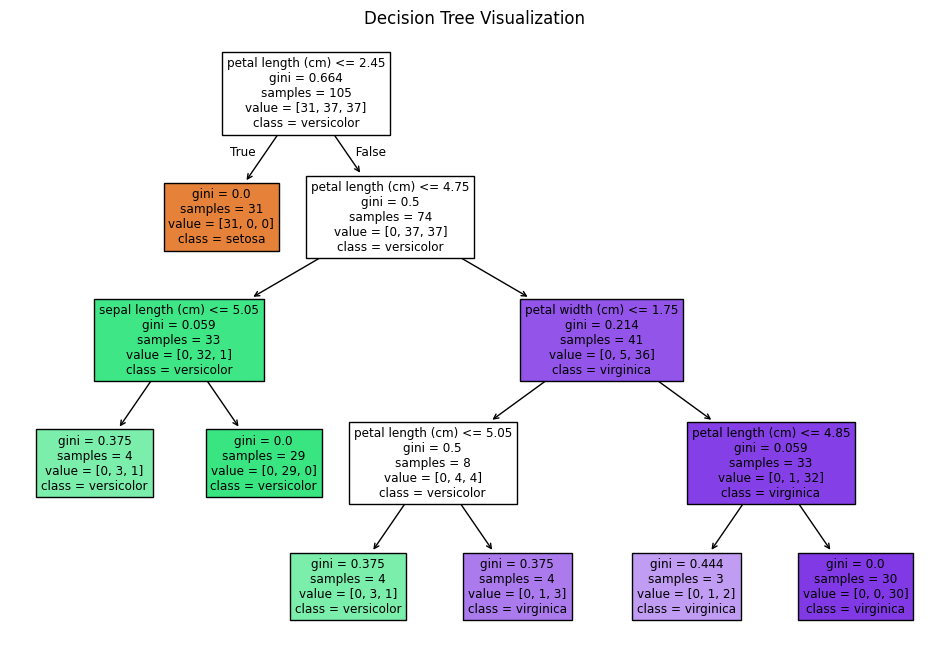

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
import matplotlib.pyplot as plt

# Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define Decision Tree with Hyperparameters
dt_model = DecisionTreeClassifier(
    criterion='gini',         # Impurity criterion
    max_depth=4,              # Limit tree depth
    min_samples_split=5,      # Minimum samples to split a node
    min_samples_leaf=3,       # Minimum samples per leaf node
    random_state=42
)

# Train the Model
dt_model.fit(X_train, y_train)

# Predictions
y_pred = dt_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualizing the Decision Tree
plt.figure(figsize=(12, 8))
tree.plot_tree(dt_model, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.title("Decision Tree Visualization")
plt.show()


---

## 🔍 **4. Hyperparameter Tuning with GridSearchCV**  

In [2]:
# Hyperparameter Grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'ccp_alpha': [0.0, 0.01, 0.1]  # Pruning
}

# Grid Search with Cross-Validation
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Accuracy: 0.9428571428571428



---

## 📊 **5. Visualizing Overfitting vs. Underfitting**  

| **Condition** | **Effect** |
|:---------------|:------------|
| **Underfitting** (Shallow Tree) | Low train accuracy, low test accuracy |
| **Optimal Fit** (Balanced Tree) | High train accuracy, high test accuracy |
| **Overfitting** (Deep Tree) | High train accuracy, low test accuracy |


## 🔥 **6. Key Takeaways**  

✅ Use `max_depth` and `min_samples_split` to control **overfitting**.  
✅ Use `ccp_alpha` (Cost Complexity Pruning) to improve **generalization**.  
✅ For small datasets, prefer **`gini`** for faster computation.  
✅ For interpretable models with fewer splits, use **`entropy`**.  
✅ Always evaluate performance with **Cross-Validation** to prevent overfitting.

💡 **Pro Tip:** Use **GridSearchCV** or **RandomizedSearchCV** for optimal hyperparameter tuning.

---